## load packages

In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

print(os.getcwd())

/home/jovyan/sp25-student/grad-proj/nlp-chatbot-analysis


In [3]:
import warnings
warnings.filterwarnings('ignore')

## load data

In [4]:
dat = pd.read_csv('complete_data_for_tasks_undeciphered.csv')

print(dat.shape)
dat.head(5)

(25256, 16)


,prompt,topic_modeling_1,score_reason_1,score_value_1,topic_modeling_2,score_reason_2,score_value_2,topic_modeling_3,score_reason_3,score_value_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,model_a,model_b,winner
0,What is the difference between OpenCL and CUDA?,Technical Comparison,This prompt requires the AI to accurately comp...,9,Software Comparison,This prompt assesses the AI's factual accuracy...,8,"Comparison, Technology",This prompt requires the AI to demonstrate kno...,9,16,0,16,chatglm-6b,koala-13b,model_b
1,Why did my parent not invite me to their wedding?,"Reasoning, Emotion",This prompt requires the AI to understand huma...,9,"Emotions, Relationships",This prompt involves understanding complex hum...,8,"Reasoning, Emotional",This prompt challenges the AI to infer motives...,8,1,1,1,oasst-pythia-12b,alpaca-13b,tie
2,"Fuji vs. Nikon, which is better?",Camera comparison,This prompt does not require problem-solving s...,2,Comparative Analysis,This prompt assesses the AI's ability to analy...,6,Photography comparison,This prompt is subjective and does not provide...,2,2,16,2,koala-13b,oasst-pythia-12b,model_b
3,How to build an arena for chatbots?,Chatbot Arena,This prompt requires problem-solving skills an...,8,Chatbot Arena,This prompt requires the AI to engage in probl...,8,Chatbot Arena,This prompt requires problem-solving skills an...,8,19,19,19,vicuna-13b,oasst-pythia-12b,model_b
4,When is it today?,Time Query,This prompt is very straightforward and does n...,2,Date Inquiry,This prompt is very straightforward and does n...,2,Time-based Inquiry,This prompt is too straightforward and simply ...,2,16,16,16,vicuna-13b,koala-13b,model_a


## cluster meaning decipher

In [5]:
# extract topics and clusters
# expand them vertically
topics_df = dat[['topic_modeling_1','topic_modeling_2','topic_modeling_3']].melt(value_name="topics")['topics']
clusters_df = dat[['topic_modeling_1_cluster','topic_modeling_2_cluster','topic_modeling_3_cluster']].melt(value_name="clusters")['clusters']

dat_useful = pd.merge(left=topics_df, right=clusters_df, how='inner', left_index=True, right_index=True)

# lowercase transformation
dat_useful['topics'] = dat_useful['topics'].str.lower()

# remove non-alphabetical characters in topics
dat_useful['topics'] = dat_useful['topics'].str.replace(r'[^a-z\s-]', '', regex=True)

print(dat_useful.shape)
dat_useful.head()

(75768, 2)


,topics,clusters
0,technical comparison,16
1,reasoning emotion,1
2,camera comparison,2
3,chatbot arena,19
4,time query,16


In [6]:
# find unique topics in each cluster
series_useful = dat_useful.groupby('clusters')['topics'].apply(set)
series_useful

clusters
0     {comparison operating systems, bike definition...
1     {reasoning emotional, therapeutic dialogue, me...
2     {crossbreeding naming, vehicle identification,...
3     {tower of hanoi, comedy sketch, interpretation...
4     {research technologies, social media writing, ...
5     {safety scenario, biomedical annotation, genet...
6     {array reversal, palindrome check, counting le...
7     {sports terminology, cognitive warfare, chess ...
8     {philosophy multiverse, factual comparison, fa...
9     {market trend, economic interdependence, portf...
10    {automated optimization, integral calculation,...
11    {current calculation, chemical compatibility, ...
12    {creativity empathy, adaptation combination, c...
13    {recommendation rating, military ships, activi...
14    {form completion, language checking, text merg...
15    {law punishment, legislator vendor, values bel...
16    {prediction missing data, causality dilemma, t...
17    {java virtual machine, template g

In [7]:
# for each cluster, concatenate all topic strings together
# perform a counter of each unique word in the cluster
counterL = []
for cluster_id in range(30):
    temp_str = ''
    for topic_id in series_useful.iloc[cluster_id]:
        temp_str = temp_str + topic_id + ' '
    temp_words = re.findall(r'[a-z-]+', temp_str)
    temp_counter = Counter(temp_words)
    print('cluster:', cluster_id)
    print(temp_counter.most_common(3))
    counterL.append(temp_counter)

cluster: 0
[('technology', 66), ('engineering', 30), ('technical', 28)]
cluster: 1
[('emotional', 51), ('psychology', 40), ('relationship', 34)]
cluster: 2
[('identification', 96), ('classification', 64), ('naming', 44)]
cluster: 3
[('poetry', 152), ('music', 111), ('humor', 96)]
cluster: 4
[('summarization', 107), ('research', 70), ('writing', 59)]
cluster: 5
[('medical', 95), ('biology', 79), ('health', 69)]
cluster: 6
[('counting', 78), ('sorting', 61), ('number', 36)]
cluster: 7
[('game', 113), ('gaming', 103), ('sports', 70)]
cluster: 8
[('factual', 96), ('philosophy', 81), ('accuracy', 67)]
cluster: 9
[('financial', 78), ('finance', 58), ('analysis', 42)]
cluster: 10
[('programming', 319), ('python', 83), ('coding', 77)]
cluster: 11
[('physics', 216), ('chemistry', 93), ('explanation', 32)]
cluster: 12
[('creativity', 455), ('creative', 106), ('art', 33)]
cluster: 13
[('recommendation', 81), ('travel', 47), ('ranking', 39)]
cluster: 14
[('language', 199), ('text', 79), ('translat

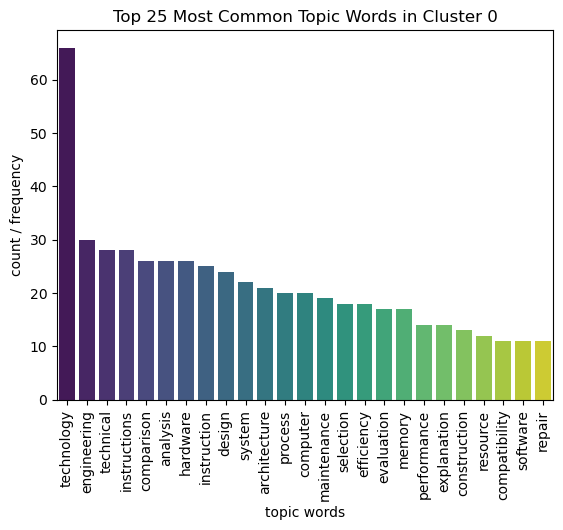

In [8]:
topics, counts = zip(*counterL[0].most_common(25))

sns.barplot(x=list(topics), y=list(counts), palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('topic words')
plt.ylabel('count / frequency')
plt.title('Top 25 Most Common Topic Words in Cluster 0')
plt.show()

In [9]:
condA = (dat['topic_modeling_1_cluster'] == 0)
condB = (dat['topic_modeling_2_cluster'] == 0)
condC = (dat['topic_modeling_3_cluster'] == 0)
dat.loc[condA & condB & condC].head()

,prompt,topic_modeling_1,score_reason_1,score_value_1,topic_modeling_2,score_reason_2,score_value_2,topic_modeling_3,score_reason_3,score_value_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,model_a,model_b,winner
30,How do you change the oil on a Porsche 911?,Mechanical Procedure,This prompt assesses the AI's problem-solving ...,7,Maintenance Procedure,This prompt assesses the AI's knowledge of a s...,6,Maintenance Procedure,This prompt assesses the AI's factual accuracy...,7,0,0,0,vicuna-13b,oasst-pythia-12b,model_b
136,What is more efficient: a right-click menu or ...,Efficiency Comparison,This prompt requires critical thinking to eval...,8,Efficiency Assessment,This prompt requires comparison and analysis o...,7,Efficiency Comparison,This prompt requires the AI to evaluate the ef...,7,0,0,0,alpaca-13b,koala-13b,model_b
192,Why did they build Washburn tunnel (near Houst...,Infrastructure Decision,This prompt requires the AI assistant to consi...,7,Infrastructure Decision,This prompt requires understanding of infrastr...,7,Infrastructure Decision,This prompt evaluates the AI's ability to expl...,7,0,0,0,alpaca-13b,vicuna-13b,tie
265,What is the best end to end testing software t...,Software Evaluation,This prompt assesses the AI's ability to recom...,7,Software Evaluation,This prompt evaluates the AI's ability to reco...,7,Software Evaluation,This prompt primarily assesses the AI's knowle...,6,0,0,0,vicuna-13b,llama-13b,model_a
274,Can you briefly describe what hotwiring a car ...,Automotive Technology,This prompt primarily assesses factual accurac...,7,Vehicle Mechanics,This prompt assesses the AI's factual accuracy...,7,Automotive Skills,This prompt assesses factual accuracy as it re...,7,0,0,0,dolly-v2-12b,vicuna-13b,model_a


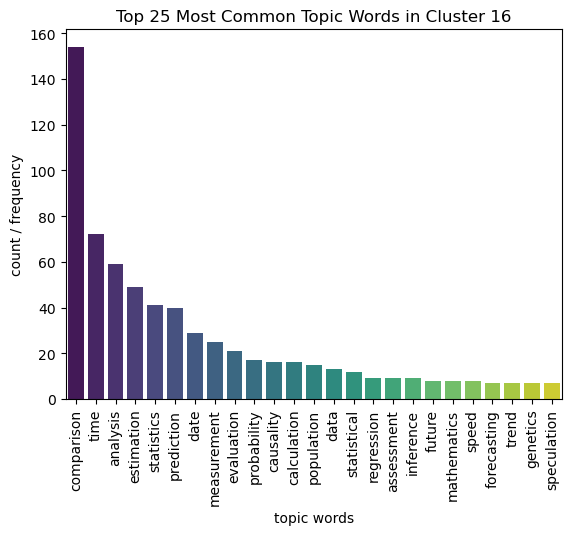

In [10]:
topics, counts = zip(*counterL[16].most_common(25))

sns.barplot(x=list(topics), y=list(counts), palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('topic words')
plt.ylabel('count / frequency')
plt.title('Top 25 Most Common Topic Words in Cluster 16')
plt.show()

In [11]:
condA = (dat['topic_modeling_1_cluster'] == 16)
condB = (dat['topic_modeling_2_cluster'] == 16)
condC = (dat['topic_modeling_3_cluster'] == 16)
dat.loc[condA & condB & condC].head()

,prompt,topic_modeling_1,score_reason_1,score_value_1,topic_modeling_2,score_reason_2,score_value_2,topic_modeling_3,score_reason_3,score_value_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,model_a,model_b,winner
4,When is it today?,Time Query,This prompt is very straightforward and does n...,2,Date Inquiry,This prompt is very straightforward and does n...,2,Time-based Inquiry,This prompt is too straightforward and simply ...,2,16,16,16,vicuna-13b,koala-13b,model_a
33,ok so i missed doomer. what's the next big thi...,Future Prediction,This prompt challenges the AI to predict futur...,8,future prediction,This prompt challenges the AI to predict a fut...,8,Future prediction,This prompt involves predicting the next big t...,8,16,16,16,koala-13b,oasst-pythia-12b,model_b
80,"An urn contains 15 blue marbles, 15 red marble...","Probability, Average Calculation",This prompt requires a good understanding of p...,9,Probability Analysis,This prompt requires a deep understanding of p...,9,Probability Analysis,This prompt requires the AI to understand the ...,8,16,16,16,koala-13b,llama-13b,tie
133,Explain to me why AI is superior to the human ...,"Comparison, Superiority",This prompt is not well-suited for evaluating ...,2,"Comparison, Superiority",This prompt is not well-designed as it present...,2,Comparison Analysis,This prompt can assess an AI's ability to prov...,9,16,16,16,chatglm-6b,vicuna-13b,model_b
139,Think step by step and explain the main differ...,Comparison Analysis,This prompt requires the AI to analyze and com...,8,"Comparison, Explanation",This prompt requires the AI to not only identi...,9,Comparison Analysis,This prompt requires critical thinking to brea...,8,16,16,16,vicuna-13b,oasst-pythia-12b,model_a


## replace cluster ids with deciphered meanings

In [12]:
replace_dict = {}

for i in range(30):
    temp_most_common = counterL[i].most_common(2)
    temp_str_a = temp_most_common[0][0]
    temp_str_b = temp_most_common[1][0]
    replace_dict[i] = temp_str_a[0].upper() + temp_str_a[1:] + ', ' + temp_str_b[0].upper() + temp_str_b[1:]

replace_dict[18] = replace_dict[18][:2].upper() + replace_dict[18][2:]
replace_dict

{0: 'Technology, Engineering',
 1: 'Emotional, Psychology',
 2: 'Identification, Classification',
 3: 'Poetry, Music',
 4: 'Summarization, Research',
 5: 'Medical, Biology',
 6: 'Counting, Sorting',
 7: 'Game, Gaming',
 8: 'Factual, Philosophy',
 9: 'Financial, Finance',
 10: 'Programming, Python',
 11: 'Physics, Chemistry',
 12: 'Creativity, Creative',
 13: 'Recommendation, Travel',
 14: 'Language, Text',
 15: 'Ethics, Legal',
 16: 'Comparison, Time',
 17: 'Programming, Development',
 18: 'AI, Task',
 19: 'Communication, Chatbot',
 20: 'History, Historical',
 21: 'Data, Database',
 22: 'Evaluation, Analysis',
 23: 'Food, Recipe',
 24: 'Geography, Astronomy',
 25: 'Problem-solving, Optimization',
 26: 'Mathematics, Mathematical',
 27: 'Security, Cybersecurity',
 28: 'Storytelling, Role-playing',
 29: 'Logic, Reasoning'}

In [13]:
temp_cols = ['topic_modeling_1_cluster','topic_modeling_2_cluster','topic_modeling_3_cluster']
dat[temp_cols] = dat[temp_cols].replace(to_replace=replace_dict)

dat.head()

,prompt,topic_modeling_1,score_reason_1,score_value_1,topic_modeling_2,score_reason_2,score_value_2,topic_modeling_3,score_reason_3,score_value_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,model_a,model_b,winner
0,What is the difference between OpenCL and CUDA?,Technical Comparison,This prompt requires the AI to accurately comp...,9,Software Comparison,This prompt assesses the AI's factual accuracy...,8,"Comparison, Technology",This prompt requires the AI to demonstrate kno...,9,"Comparison, Time","Technology, Engineering","Comparison, Time",chatglm-6b,koala-13b,model_b
1,Why did my parent not invite me to their wedding?,"Reasoning, Emotion",This prompt requires the AI to understand huma...,9,"Emotions, Relationships",This prompt involves understanding complex hum...,8,"Reasoning, Emotional",This prompt challenges the AI to infer motives...,8,"Emotional, Psychology","Emotional, Psychology","Emotional, Psychology",oasst-pythia-12b,alpaca-13b,tie
2,"Fuji vs. Nikon, which is better?",Camera comparison,This prompt does not require problem-solving s...,2,Comparative Analysis,This prompt assesses the AI's ability to analy...,6,Photography comparison,This prompt is subjective and does not provide...,2,"Identification, Classification","Comparison, Time","Identification, Classification",koala-13b,oasst-pythia-12b,model_b
3,How to build an arena for chatbots?,Chatbot Arena,This prompt requires problem-solving skills an...,8,Chatbot Arena,This prompt requires the AI to engage in probl...,8,Chatbot Arena,This prompt requires problem-solving skills an...,8,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot",vicuna-13b,oasst-pythia-12b,model_b
4,When is it today?,Time Query,This prompt is very straightforward and does n...,2,Date Inquiry,This prompt is very straightforward and does n...,2,Time-based Inquiry,This prompt is too straightforward and simply ...,2,"Comparison, Time","Comparison, Time","Comparison, Time",vicuna-13b,koala-13b,model_a


In [14]:
dat.to_csv('complete_data_for_tasks_deciphered.csv', index=False)

In [16]:
hayden_cluster_test = pd.read_csv('hayden_cluster_test.csv')
hayden_cluster_test[temp_cols] = hayden_cluster_test[temp_cols].replace(to_replace=replace_dict)

print(hayden_cluster_test.shape)
hayden_cluster_test.head()

(3200, 8)


,question_id,prompt,topic_modeling_1,topic_modeling_2,topic_modeling_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster
0,4f332ebd8cdc4ff2be74aa8828ff20d5,what do you think about the future of iran?,Future Prediction,Future Prediction,Future Prediction,"Comparison, Time","Comparison, Time","Comparison, Time"
1,f2be6f13e5ed40e5b81443223996494c,Salut ! Tu es un méchant chatbot !,"Role-playing, Evaluation","Role-play, Evaluation","Creativity, Factual Accuracy","Storytelling, Role-playing","Storytelling, Role-playing","Factual, Philosophy"
2,5fafefb8a0c54243afb52d2892946cea,⚔️ Chatbot Arena ⚔️\nRules:\n Chat with two...,Chatbot Evaluation,Chatbot Evaluation,Chatbot Evaluation,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot"
3,7834f572267f40709ecebb273a2b346b,Guess the word that i have in my mind,Guessing Game,Word Guessing,Word Guessing,"Counting, Sorting","Counting, Sorting","Counting, Sorting"
4,1ccc7e58290245c4bd5457fce45f8640,You are a peasant living in the village. But s...,"Problem-Solving, Creativity",Problem Solving,"Problem-solving, Creativity","Creativity, Creative","Problem-solving, Optimization","Creativity, Creative"


In [17]:
hayden_cluster_test.to_csv('hayden_cluster_test_deciphered.csv', index=False)